<a href="https://colab.research.google.com/github/AlxScottt/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

Sources: Used ChatGPT accssed at https://chatgpt.com/ to help me code, double check my summarys, and double check my math.

Sources I used for the part 1 questions.

https://www.geeksforgeeks.org/machine-learning/ridge-regression-vs-lasso-regression/
3 soruce

https://medium.com/@chirag.abhatia/mls-3-regularization-and-scaling-diving-into-the-mathematics-95031b7a68d2
4 soruce


**Q1.** Please answer the following questions in your own words.

1. **What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?**

Basically, you add a penalty term based on the size of the model parameters, which constrains the models complexity to prevent overfitting.

2. **How does regularization provide a way of exploring the bias-variance trade-off?**

When you penalize large coeffiencets, the regulazation makes it so the model doesent fit the noise in the training data, in the end reudcing the varaince and mitigating overfitting.

3. **What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?**

I cited this.

Ridge Regression, also known as L2 regularization, adds the squared magnitude of the coefficients as a penalty.
On the other hand, Lasso Regression, or L1 regularization, introduces a penalty based on the absolute value of the coefficients.

4. **How do we typically scale variables for use in regularized regression? Why?**
cited

The magnitude of coefficients depend on the strength of the relation between x and y and also on the units of measurement of the inputs. It is important to scale the inputs before regularizing so that regularization does not have to deal with scale caused by different units of measurement.

5. **How is the penalty $\alpha$ typically selected?**

Its selected using cross-validation to minimize the cross-validated generalization error, such as mean squared error or deviance.

6. **When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?**

No, use the penalty to train the model, but use plain MSE to evaluate it.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [72]:
import pandas as pd #import statments or else nothing works
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

#you gotta load the dataa!!!
df = pd.read_csv("cars_hw.csv")

#Create Age based on the right year
df["Age"] = 2024 - df["Make_Year"]

#Select the features that you want!
X = df[["Mileage_Run", "Age"]]
y = df["Price"]

# hopefully did right with 3 degree
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# scaler, used the one in the directions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [73]:
#2
lr = LinearRegression()
lr.fit(X_scaled, y)
coeffs = pd.Series(lr.coef_, index=feature_names)
print(coeffs)

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


#2
The sign between the two is negative, This indicates that cars with both higher mileage and greater age experience a stronger decrease in price.

In [74]:
#3
alphas = np.logspace(1, 3, 20) #1, 3, 20
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20, max_iter=10000)

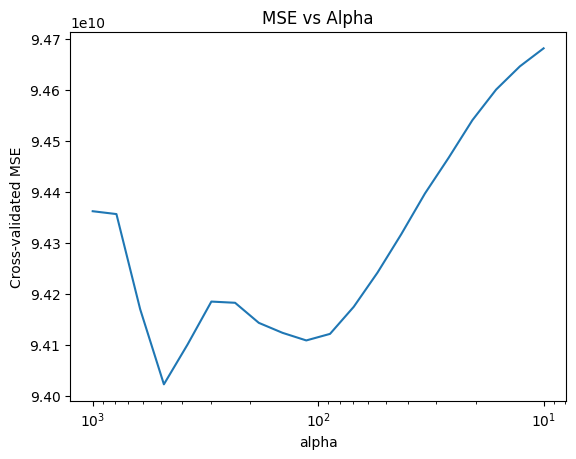

In [75]:
#4
mean_mse = np.mean(lasso.mse_path_, axis=1) #mean

plt.plot(lasso.alphas_, mean_mse) #plottt time
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.gca().invert_xaxis()
plt.show()

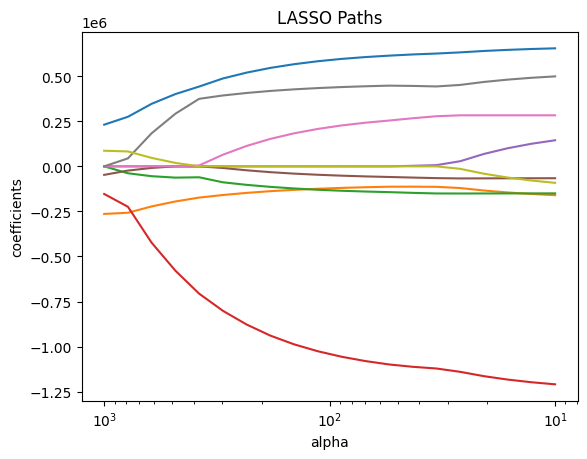

In [76]:
#5
coefs = [] #place to store

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_) #append it to the list

coefs = np.array(coefs)

for i in range(coefs.shape[1]): #go through them and plot
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("LASSO Paths")
plt.gca().invert_xaxis()
plt.show()

In [77]:
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
num_zero = np.sum(lasso_coefs == 0)

print("Selected features:")
print(selected)

print("\nProportion zero:")
print(num_zero / len(lasso_coefs))

Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64

Proportion zero:
0.3333333333333333


#6

Lasso slected 6 out of the 9 features, so 3 went to 0, so 33.3% are eleminated.

In [78]:
comparison = pd.DataFrame({
    "Linear": coeffs,
    "LASSO": lasso_coefs
})

print(comparison)

                         Linear          LASSO
Mileage_Run        6.686165e+05  401025.259657
Age               -1.841941e+05 -194803.116695
Mileage_Run^2     -1.494679e+05  -62539.290093
Mileage_Run Age   -1.251592e+06 -578788.661090
Age^2              2.156399e+05      -0.000000
Mileage_Run^3     -6.514490e+04      -0.000000
Mileage_Run^2 Age  2.833392e+05       0.000000
Mileage_Run Age^2  5.280829e+05  292015.025679
Age^3             -1.389370e+05   19133.908573


#7
None of them go up significantly, they either shrink or go to 0.


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [79]:
import pandas as pd #imports again
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso

#Load data into the filee!!
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

#we get our target varible
y = df["DEATH_EVENT"]

# the other contuinus ones
cont = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(cont)
cont_names = poly_cont.get_feature_names_out(cont.columns)

#scale them
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

#catgorlical ones
cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(cat)
cat_names = poly_cat.get_feature_names_out(cat.columns)

#combine them
X = np.hstack([X_cont_scaled, X_cat])
feature_names = list(cont_names) + list(cat_names)

In [80]:
lr = LinearRegression() #regerssion part
lr.fit(X, y)

coeffs = pd.Series(lr.coef_, index=feature_names)
print(coeffs.sort_values())

age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
smoking                                  -0.102687
age ejection_fraction^2                  -0.081206
diabetes                                 -0.070705
anaemia high_blood_pressure              -0.027251
high_blood_pressure                      -0.007934
anaemia                                   0.008093
anaemia diabetes                          0.026159
anaemia smoking                           0.064908
serum_creatinine^3                        0.072156
high_blood_pressure smoking               0.101455
diabetes high_blood_pressure   

#2
ejection_fraction is negative (-2.19)

but ejection_fraction^2 is positive (+3.43)

and ejection_fraction * serum_creatinine is positive (+2.67)

So combineing and squaring it makes it postive?

Also serum_creatinine appears with a negative coefficient (-0.853588), which goes agasint what we have seen in class multiple times, that higher creatinine levels should increase risk.

In [81]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso.fit(X, y)

LassoCV(alphas=array([1.00000000e-05, 2.21221629e-05, 4.89390092e-05, 1.08263673e-04,
       2.39502662e-04, 5.29831691e-04, 1.17210230e-03, 2.59294380e-03,
       5.73615251e-03, 1.26896100e-02, 2.80721620e-02, 6.21016942e-02,
       1.37382380e-01, 3.03919538e-01, 6.72335754e-01, 1.48735211e+00,
       3.29034456e+00, 7.27895384e+00, 1.61026203e+01, 3.56224789e+01,
       7.88046282e+01, 1.74332882e+02, 3.85662042e+02, 8.53167852e+02,
       1.88739182e+03, 4.17531894e+03, 9.23670857e+03, 2.04335972e+04,
       4.52035366e+04, 1.00000000e+05]),
        cv=20, max_iter=100000)

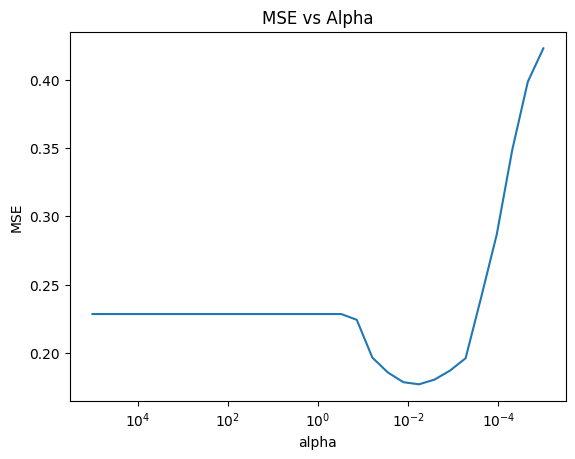

In [82]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("MSE vs Alpha")
plt.gca().invert_xaxis()
plt.show()

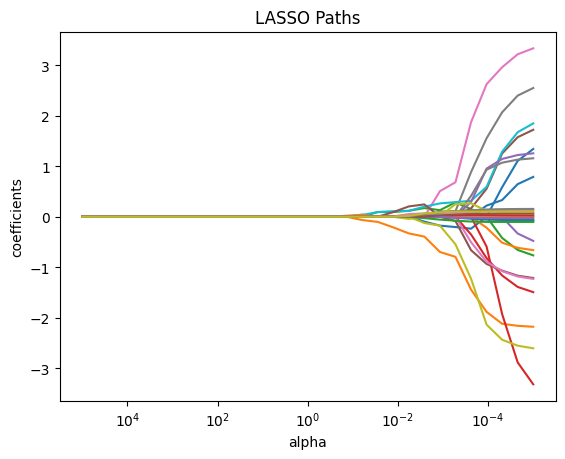

In [83]:
coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("LASSO Paths")
plt.gca().invert_xaxis()
plt.show()

In [84]:
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
num_zero = np.sum(lasso_coefs == 0)

print("Selected features:")
print(selected)

print("Proportion zero:", num_zero / len(lasso_coefs))

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion zero: 0.5862068965517241


#7 (used chat to help sum greatly)
The LASSO model selects a smaller subset of features and sets about 58.6% of the coefficients to zero, showing strong feature selection. Compared to linear regression, most coefficients shrink in magnitude, and some change sign, such as serum_creatinine, which becomes more consistent with medical expectations. The LASSO model’s sign patterns are more reasonable because it removes correlated and redundant features. This happens due to the bias–variance trade-off, where LASSO adds some bias but greatly reduces variance, leading to more stable and interpretable results.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

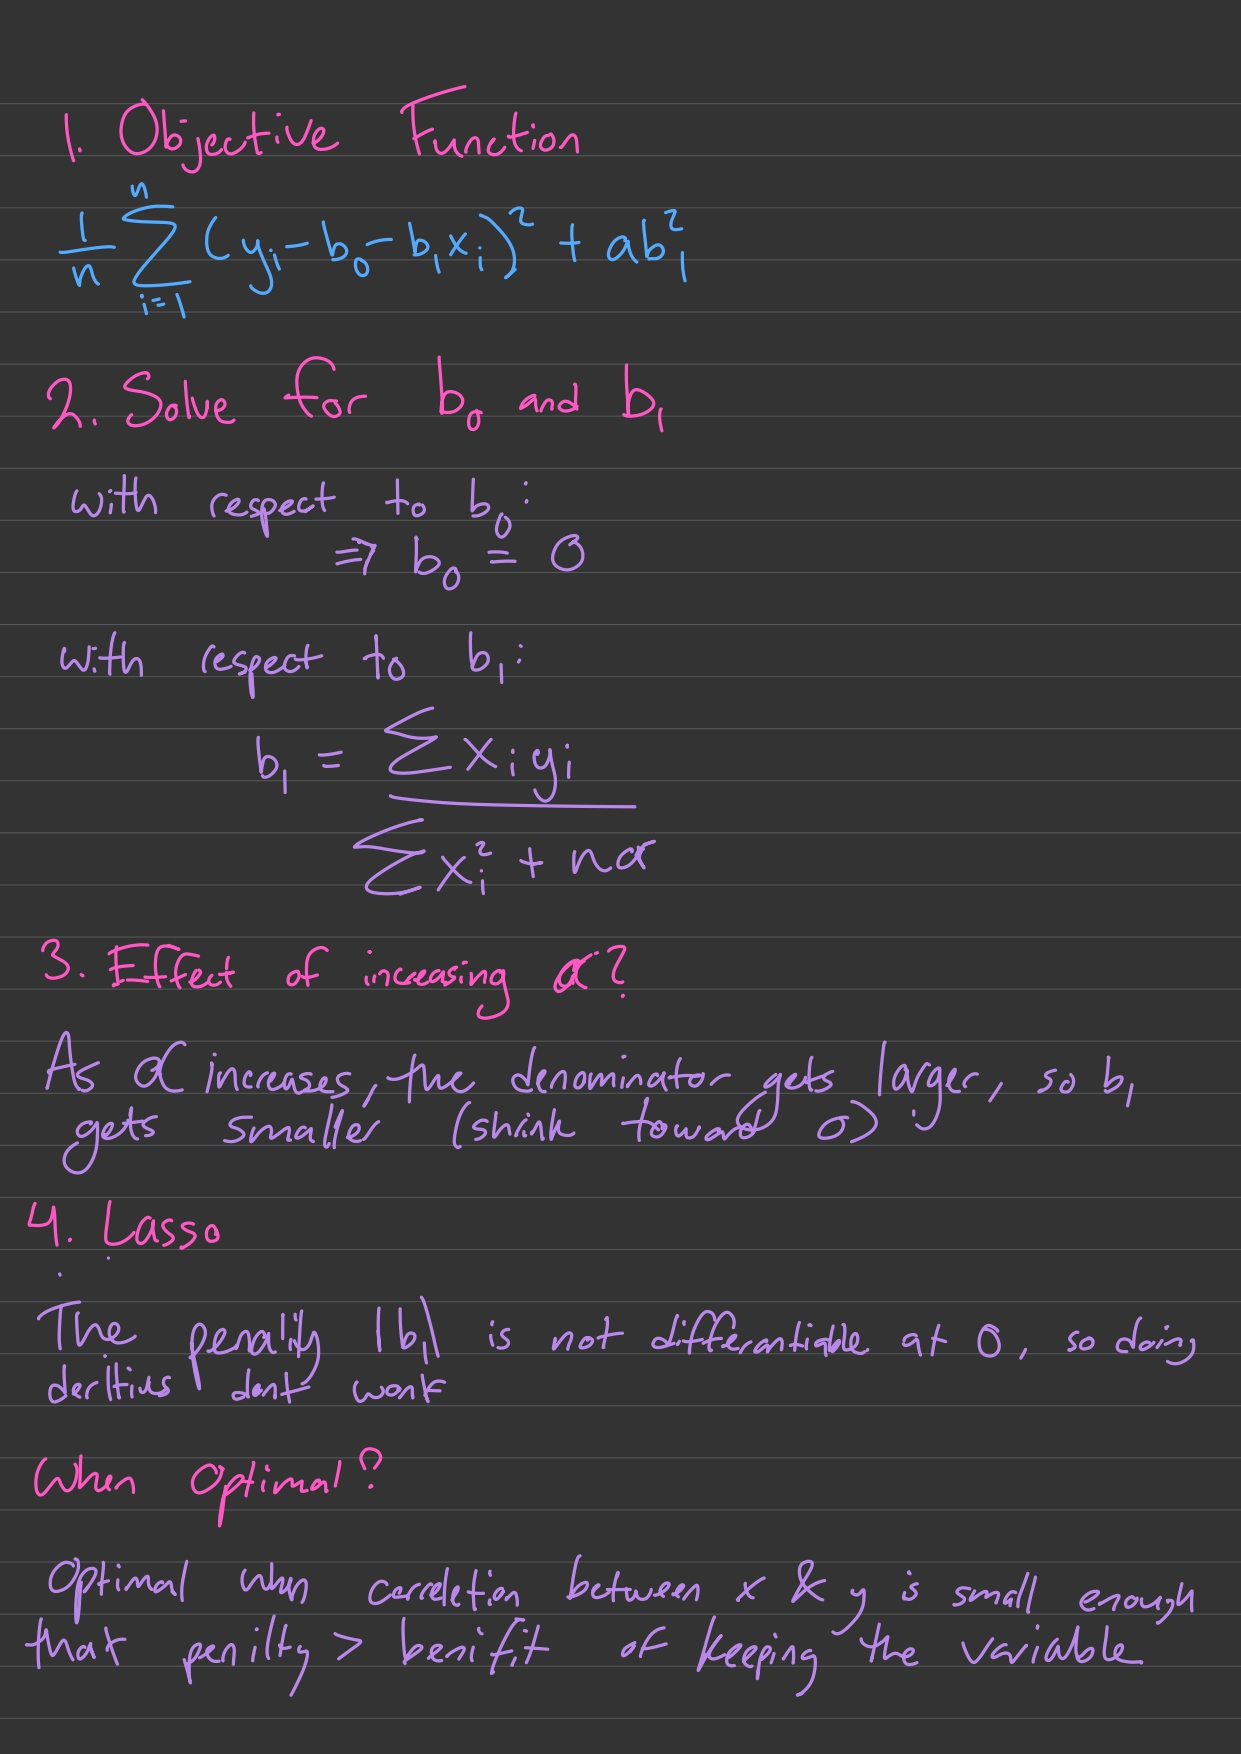